# Hyperparameter tuning

### Grid, random, halving, and a Bayesian search written by hand

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why a grid wastes most of its budget when only a few hyperparameters matter, how random search fixes that, what halving buys on a small budget, how to write a Bayesian search yourself, why learning rates and regularisation want log-uniform sampling, and why the score that came out of a search is too high |
| **You should already know** | [Cross-validation](../04-cross-validation/), [overfitting and underfitting](../03-overfitting-and-underfitting/) |
| **Datasets** | UCI Dry Bean, Breast Cancer Wisconsin |
| **Runtime** | About three minutes on a laptop CPU |
| **Next** | [02-01 Linear regression](../../02-regression/01-linear-regression/) |

---

## 1. The problem

Model parameters are fitted. Hyperparameters are not. The depth of a tree, the
$C$ of a support vector machine, the learning rate of a gradient booster: you
choose those, and the model has no way to tell you that you chose badly except by
scoring worse.

So tuning is a search. Propose a setting, score it by
[cross-validation](../04-cross-validation/), keep the best one. Three things make
that harder than it sounds.

The score is noisy, because it comes from a finite validation set. Each
evaluation is expensive, because it costs a full round of cross-validation. And
the number of combinations grows as a power of the number of hyperparameters, so
the obvious method, try everything, stops being possible almost immediately.

This notebook is about spending a fixed budget of evaluations well.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. Grid search and its cost

A grid is the method everyone writes first. List a few values for each
hyperparameter, take every combination, score them all, keep the winner.

It has one genuine virtue: it is exhaustive over the values you listed, so it
cannot miss a combination you asked for. Everything else about it is a problem.

Here it is on a decision tree over four hyperparameters, on a slice of the Dry
Bean data.

In [2]:
import time

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

X_all, y_all = datasets.dry_bean()
pick = np.random.default_rng(SEED).choice(len(X_all), 3000, replace=False)
X_bean, y_bean = X_all.values[pick], y_all.values[pick]

FOLDS = 3
tree_grid = {
    "max_depth": [3, 5, 8, 12],
    "min_samples_leaf": [1, 5, 20, 50],
    "max_features": [None, "sqrt", 0.5],
    "criterion": ["gini", "entropy"],
}

search = GridSearchCV(DecisionTreeClassifier(random_state=SEED), tree_grid,
                      cv=StratifiedKFold(FOLDS, shuffle=True, random_state=SEED),
                      n_jobs=-1)
start = time.perf_counter()
search.fit(X_bean, y_bean)
grid_wall = time.perf_counter() - start

# Time one fit on its own, because n_jobs=-1 hides the real per-fit cost and the
# extrapolation in the next cell needs the honest number.
fit_times = []
for _ in range(5):
    t0 = time.perf_counter()
    DecisionTreeClassifier(random_state=SEED).fit(X_bean[:2000], y_bean[:2000])
    fit_times.append(time.perf_counter() - t0)
one_fit = float(np.median(fit_times))

candidates = len(search.cv_results_["mean_test_score"])
scores = search.cv_results_["mean_test_score"]

print(f"candidates      : {candidates}")
print(f"fits performed  : {candidates * FOLDS}")
print(f"wall time       : {grid_wall:.1f} s  (all cores)")
print(f"one fit alone   : {one_fit * 1000:.1f} ms")
print()
print(f"best score      : {scores.max():.4f}")
print(f"median candidate: {np.median(scores):.4f}")
print(f"worst candidate : {scores.min():.4f}")
print(f"best params     : {search.best_params_}")

candidates      : 96
fits performed  : 288
wall time       : 16.1 s  (all cores)
one fit alone   : 40.9 ms

best score      : 0.9000
median candidate: 0.8780
worst candidate : 0.7043
best params     : {'criterion': 'entropy', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 5}


The spread between the best and the worst setting is large enough that tuning is
clearly worth doing. The trouble is what happens when the grid grows.

With $d$ hyperparameters and $k$ values each, a grid is $k^d$ combinations, and
each combination costs one round of cross-validation. The exponent is the whole
story.

per-fit time used: 40.9 ms
k= 3, d=4:        81 combinations,       0.00 hours
k= 3, d=6:       729 combinations,       0.02 hours
k= 3, d=8:     6,561 combinations,       0.22 hours
k= 5, d=4:       625 combinations,       0.02 hours
k= 5, d=6:    15,625 combinations,       0.53 hours
k= 5, d=8:   390,625 combinations,      13.33 hours
k=10, d=4:    10,000 combinations,       0.34 hours
k=10, d=6: 1,000,000 combinations,      34.11 hours
k=10, d=8: 100,000,000 combinations,    3411.39 hours


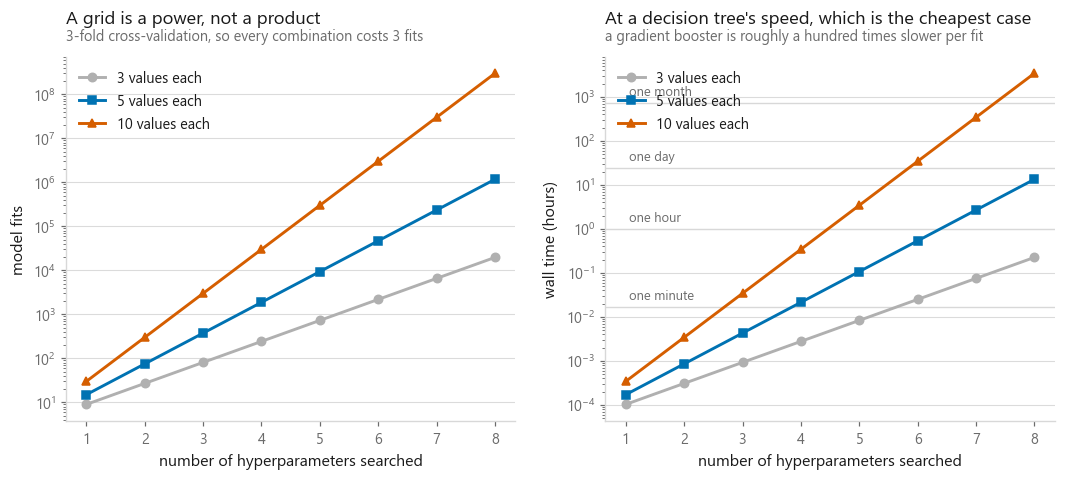

In [3]:
d_axis = np.arange(1, 9)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))

for i, (k, colour) in enumerate(zip([3, 5, 10],
                                    [style.NEUTRAL, style.PALETTE[0], style.HIGHLIGHT])):
    fits = (float(k) ** d_axis) * FOLDS
    axes[0].plot(d_axis, fits, marker=style.MARKERS[i], color=colour,
                 label=f"{k} values each")
    axes[1].plot(d_axis, fits * one_fit / 3600, marker=style.MARKERS[i], color=colour,
                 label=f"{k} values each")

axes[0].set_yscale("log")
axes[0].set_ylabel("model fits")
style.title(axes[0], "A grid is a power, not a product",
            f"{FOLDS}-fold cross-validation, so every combination costs {FOLDS} fits")

axes[1].set_yscale("log")
axes[1].set_ylabel("wall time (hours)")
for hours, label in [(1 / 60, "one minute"), (1, "one hour"), (24, "one day"),
                     (24 * 30, "one month")]:
    axes[1].axhline(hours, color=style.RULE, lw=0.9, zorder=0)
    axes[1].annotate(label, xy=(1, hours), xytext=(2, 3), textcoords="offset points",
                     fontsize=8.5, color=style.MUTED, va="bottom")
style.title(axes[1], "At a decision tree's speed, which is the cheapest case",
            "a gradient booster is roughly a hundred times slower per fit")

for ax in axes:
    ax.set_xlabel("number of hyperparameters searched")
    ax.legend(loc="upper left")
style.save(fig, FIG / "fig-01-grid-cost.png")

print(f"per-fit time used: {one_fit * 1000:.1f} ms")
for k in [3, 5, 10]:
    for d in [4, 6, 8]:
        hours = (k ** d) * FOLDS * one_fit / 3600
        print(f"k={k:>2}, d={d}: {k ** d:>9,} combinations, {hours:>10.2f} hours")

Adding one hyperparameter to a grid is one line of typing and multiplies the bill
by $k$. The table above is for a decision tree, which is the cheapest model in
this book; anything slower per fit scales all of those times up by the same
factor.

The usual reaction is to shrink $k$: try three values per hyperparameter instead
of ten. That is where the real damage happens, and it is the subject of the next
section.

## 3. Why random beats grid when few parameters matter

This is the result from Bergstra and Bengio's 2012 paper, and it is usually
quoted rather than shown. I want to show it.

The claim rests on an observation about real tuning problems: the hyperparameters
are not equally important. One or two of them move the score a lot, and the rest
barely move it at all. Which ones matter is not known in advance, which is why
they all end up in the search.

So I will build a search space with exactly that shape. Two parameters, $a$ and
$b$. Changing $a$ moves the objective a lot, over a narrow peak. Changing $b$
moves it almost not at all.

Grid: 6 values each, 36 evaluations          distinct values of a tried: 6
Random: 36 draws, 36 evaluations             distinct values of a tried: 36


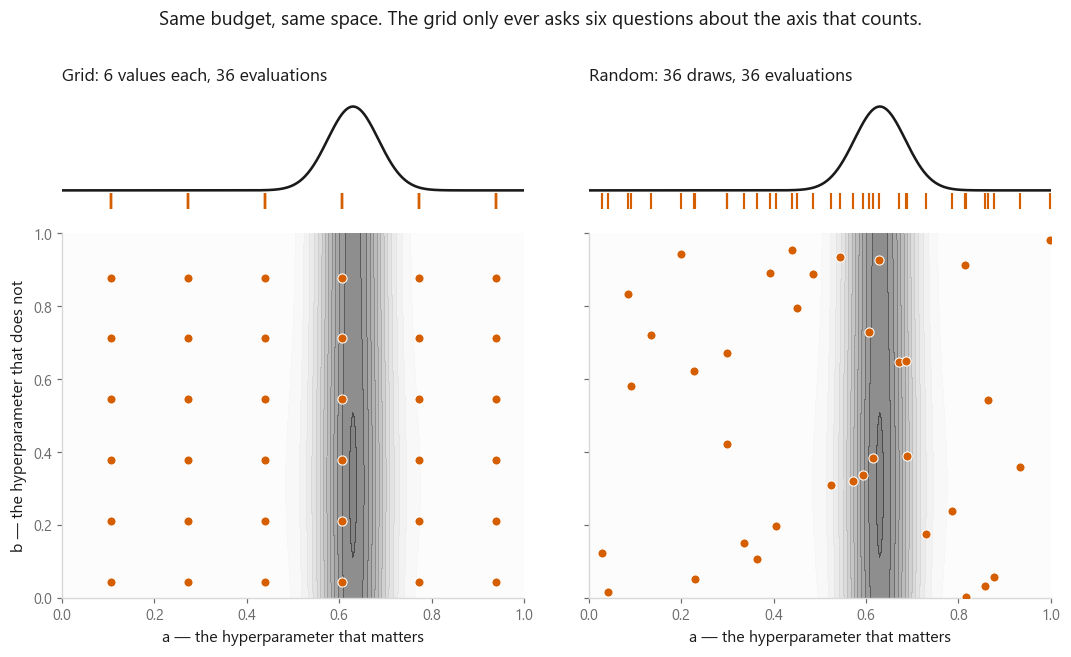

In [4]:
def objective_2d(a, b):
    """One parameter with a narrow, tall peak; one with a wide, shallow one."""
    important = np.exp(-0.5 * ((a - 0.63) / 0.055) ** 2)
    ignorable = np.exp(-0.5 * ((b - 0.31) / 0.30) ** 2)
    return important + 0.05 * ignorable


def grid_points(k, rng):
    """A k-by-k lattice with a random offset, so no grid is secretly lucky."""
    step = 1.0 / k
    offset = rng.uniform(0, step, size=2)
    a = np.linspace(0, 1, k, endpoint=False) + offset[0]
    b = np.linspace(0, 1, k, endpoint=False) + offset[1]
    mesh_a, mesh_b = np.meshgrid(a, b, indexing="ij")
    return np.column_stack([mesh_a.ravel(), mesh_b.ravel()])


def random_points(n, rng):
    return rng.uniform(0, 1, size=(n, 2))


K = 6
BUDGET = K * K
show_rng = np.random.default_rng(SEED)
sampled = {
    f"Grid: {K} values each, {BUDGET} evaluations": grid_points(K, show_rng),
    f"Random: {BUDGET} draws, {BUDGET} evaluations": random_points(BUDGET, show_rng),
}

a_line = np.linspace(0, 1, 500)
marginal = np.exp(-0.5 * ((a_line - 0.63) / 0.055) ** 2)
mesh_a, mesh_b = np.meshgrid(np.linspace(0, 1, 260), np.linspace(0, 1, 260), indexing="ij")
field = objective_2d(mesh_a, mesh_b)

fig = plt.figure(figsize=(11.6, 6.0))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 3.0], hspace=0.09, wspace=0.14)

for col, (name, pts) in enumerate(sampled.items()):
    top = fig.add_subplot(gs[0, col])
    top.plot(a_line, marginal, color=style.INK, lw=1.7)
    top.plot(pts[:, 0], np.full(len(pts), -0.13), "|", color=style.HIGHLIGHT,
             ms=11, mew=1.4)
    top.set_xlim(0, 1)
    top.set_ylim(-0.25, 1.2)
    top.axis("off")
    top.set_title(name, loc="left", fontsize=11.5, color=style.INK)

    main = fig.add_subplot(gs[1, col])
    main.contourf(mesh_a, mesh_b, field, levels=14, cmap="Greys", alpha=0.5)
    main.scatter(pts[:, 0], pts[:, 1], s=36, c=style.HIGHLIGHT,
                 edgecolor="white", linewidth=0.7, zorder=3)
    main.set_xlim(0, 1)
    main.set_ylim(0, 1)
    main.grid(False)
    main.set_xlabel("a — the hyperparameter that matters")
    if col == 0:
        main.set_ylabel("b — the hyperparameter that does not")
    else:
        main.tick_params(labelleft=False)

fig.suptitle("Same budget, same space. The grid only ever asks six questions "
             "about the axis that counts.",
             x=0.5, y=1.0, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-grid-vs-random.png")

for name, pts in sampled.items():
    distinct_a = len(np.unique(np.round(pts[:, 0], 9)))
    print(f"{name:<44} distinct values of a tried: {distinct_a}")

The curve along the top of each panel is the objective as a function of $a$ alone.
The ticks under it are the values of $a$ that each method actually tried.

Both methods spent the same budget. The grid spread it over a lattice, so its
thirty-six evaluations collapse onto six distinct values of $a$: the other five
evaluations at each value only varied $b$, which does nothing. Random search
spent every one of its thirty-six evaluations on a fresh value of $a$.

**A grid of $k$ values per parameter never learns more than $k$ things about any
one parameter, no matter how large the budget gets.** Random search learns as
many things as it has samples. That is the whole argument.

Now the consequence, measured over many repeats so that one lucky grid offset
cannot decide it.

In [5]:
TRIALS = 800
rng = np.random.default_rng(SEED + 1)
best_grid = np.empty(TRIALS)
best_random = np.empty(TRIALS)

for t in range(TRIALS):
    g = grid_points(K, rng)
    r = random_points(BUDGET, rng)
    best_grid[t] = objective_2d(g[:, 0], g[:, 1]).max()
    best_random[t] = objective_2d(r[:, 0], r[:, 1]).max()

print(f"budget {BUDGET} evaluations, {TRIALS} repeats, best possible is 1.05")
print(f"grid   : mean best {best_grid.mean():.4f}   worst repeat {best_grid.min():.4f}")
print(f"random : mean best {best_random.mean():.4f}   worst repeat {best_random.min():.4f}")
print(f"random wins in {(best_random > best_grid).mean():.1%} of repeats")

budget 36 evaluations, 800 repeats, best possible is 1.05
grid   : mean best 0.7638   worst repeat 0.3680
random : mean best 0.9840   worst repeat 0.3514
random wins in 78.1% of repeats


The gap widens as parameters are added, because a bigger budget buys a grid
nothing on the axis that matters. It stays stuck at $k$ distinct values while
random search gets one distinct value per evaluation.

In [6]:
def objective_nd(points):
    """First coordinate matters; the rest are the same shallow nuisance."""
    important = np.exp(-0.5 * ((points[:, 0] - 0.63) / 0.055) ** 2)
    if points.shape[1] == 1:
        return important
    nuisance = np.exp(-0.5 * ((points[:, 1:] - 0.31) / 0.30) ** 2).mean(axis=1)
    return important + 0.05 * nuisance


def grid_points_nd(k, d, rng):
    offset = rng.uniform(0, 1.0 / k, size=d)
    axes_ = [np.linspace(0, 1, k, endpoint=False) + offset[j] for j in range(d)]
    mesh = np.meshgrid(*axes_, indexing="ij")
    return np.column_stack([m.ravel() for m in mesh])


K_ND = 4
rng = np.random.default_rng(SEED + 2)
print(f"{K_ND} values per parameter, only the first parameter matters\n")
print(f"{'d':>2} {'budget':>7} {'grid values of a':>18} {'random values of a':>20} "
      f"{'grid best':>11} {'random best':>13}")
for d in [2, 3, 4, 5]:
    budget = K_ND ** d
    gb, rb = [], []
    for _ in range(150):
        gb.append(objective_nd(grid_points_nd(K_ND, d, rng)).max())
        rb.append(objective_nd(rng.uniform(0, 1, size=(budget, d))).max())
    print(f"{d:>2} {budget:>7} {K_ND:>18} {budget:>20} "
          f"{np.mean(gb):>11.4f} {np.mean(rb):>13.4f}")

4 values per parameter, only the first parameter matters

 d  budget   grid values of a   random values of a   grid best   random best
 2      16                  4                   16      0.5750        0.8640
 3      64                  4                   64      0.5297        1.0158
 4     256                  4                  256      0.5761        1.0378
 5    1024                  4                 1024      0.5929        1.0415


Random search is not magic, and the argument has a condition attached. It wins
because most of the axes are wasted effort. Take that condition away and the
advantage does not level off, it reverses, and the grid wins.

Here is that control, on a space where both parameters have equally narrow peaks.

In [7]:
def objective_both_matter(points):
    return np.exp(-0.5 * (((points - 0.63) / 0.12) ** 2).sum(axis=1))


rng = np.random.default_rng(SEED + 3)
gb, rb = [], []
for _ in range(800):
    gb.append(objective_both_matter(grid_points(K, rng)).max())
    rb.append(objective_both_matter(rng.uniform(0, 1, size=(BUDGET, 2))).max())

print("both parameters equally important, same budget")
print(f"grid   : mean best {np.mean(gb):.4f}")
print(f"random : mean best {np.mean(rb):.4f}")
print(f"random wins in {np.mean(np.array(rb) > np.array(gb)):.1%} of repeats")

both parameters equally important, same budget
grid   : mean best 0.8592
random : mean best 0.7710
random wins in 38.0% of repeats


Read that against the previous cell, because it is the mirror image of it. With
both peaks equally narrow the grid finds a better setting on average and takes the
majority of the repeats. A lattice guarantees coverage in every direction. Random
draws leave gaps, and when every direction matters a gap is a live risk of missing
the peak altogether.

So the rule is not "random is better". It is that a grid pays for resolution in
every dimension at once, and you almost never need resolution in every dimension.
On the rare occasion you do, buy it.

## 4. Halving and a hand-rolled Bayesian search

Random search has its own weakness: it never learns. Draw fifty points and the
fiftieth is chosen the same way as the first, with no reference to the
forty-nine scores already in hand. Two families of method fix that.

**Halving** spends less on each candidate at first. Score everything on a small
slice of the data, throw away the worst two thirds, give the survivors three
times the data, repeat. Bad settings get eliminated cheaply and the budget
concentrates on plausible ones.

**Bayesian optimisation** fits a model of the objective itself (a surrogate,
usually a Gaussian process) to the points evaluated so far, then uses that model
to decide where to look next.

I will build both against a real objective: the cross-validated accuracy of an
RBF support vector machine on Breast Cancer, as a function of $\log_{10} C$ and
$\log_{10} \gamma$. The dataset is small, so an evaluation is cheap enough to run
hundreds of them.

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X_bc_frame, y_bc_frame = datasets.breast_cancer()
X_bc, y_bc = X_bc_frame.values, y_bc_frame.values

SEARCH_CV = StratifiedKFold(3, shuffle=True, random_state=SEED)
# Columns are log10 C and log10 gamma. Everything below searches in log space.
BOX = np.array([[-2.0, 2.0],
                [-4.0, 0.0]])

_seen = {}


def objective(point):
    """3-fold CV accuracy of an RBF SVM at (log10 C, log10 gamma)."""
    key = (round(float(point[0]), 6), round(float(point[1]), 6))
    if key not in _seen:
        model = make_pipeline(StandardScaler(),
                              SVC(C=10.0 ** key[0], gamma=10.0 ** key[1]))
        _seen[key] = float(cross_val_score(model, X_bc, y_bc, cv=SEARCH_CV).mean())
    return _seen[key]


t0 = time.perf_counter()
probe = objective([0.0, -2.0])
print(f"rows {X_bc.shape[0]}, features {X_bc.shape[1]}")
print(f"one evaluation costs {(time.perf_counter() - t0) * 1000:.0f} ms")
print(f"score at C=1, gamma=0.01      : {probe:.4f}")
print(f"score at C=0.01, gamma=1      : {objective([-2.0, 0.0]):.4f}")
print(f"score at C=100, gamma=0.0001  : {objective([2.0, -4.0]):.4f}")

rows 569, features 30
one evaluation costs 29 ms
score at C=1, gamma=0.01      : 0.9737
score at C=0.01, gamma=1      : 0.6274
score at C=100, gamma=0.0001  : 0.9649


### Grid and random on this objective

For the grid I use the closest lattice to each budget, rather than walking one
grid in order, because a grid has no honest notion of "best so far": you have to
finish it before the answer means anything.

In [9]:
N_EVAL = 42

grid_budgets, grid_best = [], []
for n_a, n_b in [(2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]:
    axis_a = np.linspace(BOX[0, 0], BOX[0, 1], n_a)
    axis_b = np.linspace(BOX[1, 0], BOX[1, 1], n_b)
    values = [objective([a, b]) for a in axis_a for b in axis_b]
    grid_budgets.append(n_a * n_b)
    grid_best.append(max(values))

random_curves = []
for s in range(12):
    rng = np.random.default_rng(100 + s)
    pts = rng.uniform(BOX[:, 0], BOX[:, 1], size=(N_EVAL, 2))
    random_curves.append(np.maximum.accumulate([objective(p) for p in pts]))
random_curves = np.array(random_curves)

for budget, best in zip(grid_budgets, grid_best):
    print(f"grid {budget:>3} evaluations: best {best:.4f}")
print()
for n in [6, 12, 20, 30, 42]:
    print(f"random {n:>3} evaluations: best {random_curves[:, n - 1].mean():.4f} "
          f"(mean of 12 runs)")

grid   6 evaluations: best 0.9719
grid  12 evaluations: best 0.9754
grid  20 evaluations: best 0.9789
grid  30 evaluations: best 0.9772
grid  42 evaluations: best 0.9754

random   6 evaluations: best 0.9756 (mean of 12 runs)
random  12 evaluations: best 0.9775 (mean of 12 runs)
random  20 evaluations: best 0.9780 (mean of 12 runs)
random  30 evaluations: best 0.9788 (mean of 12 runs)
random  42 evaluations: best 0.9791 (mean of 12 runs)


### A Bayesian search, written out

There is no `optuna` or `scikit-optimize` here. The whole method fits in a page,
and writing it out is the only way to see that nothing is hidden.

Fit a Gaussian process to the points evaluated so far. It returns, at any new
point, a predicted mean $\mu(x)$ and a standard deviation $\sigma(x)$ saying how
unsure it is. Then score candidate points by **expected improvement** over the
best score seen so far, $f^*$:

$$\mathrm{EI}(x) = (\mu(x) - f^*)\,\Phi(z) + \sigma(x)\,\phi(z),
\qquad z = \frac{\mu(x) - f^*}{\sigma(x)}$$

where $\Phi$ and $\phi$ are the normal distribution's cumulative and density
functions. The first term rewards points the surrogate thinks are good. The
second rewards points it is unsure about. Evaluate wherever EI is largest, add
the result to the data, refit, repeat.

That second term is the part that matters. Without it the search would go
straight back to the best point it already has and stay there.

In [10]:
import warnings

from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

KERNEL = (ConstantKernel(1.0, (1e-3, 1e3))
          * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3), nu=2.5)
          + WhiteKernel(1e-4, (1e-10, 1e-1)))


def expected_improvement(mu, sigma, incumbent):
    sigma = np.maximum(sigma, 1e-9)
    z = (mu - incumbent) / sigma
    return (mu - incumbent) * norm.cdf(z) + sigma * norm.pdf(z)


def bayesian_search(n_total, n_init, seed, pool=1200, verbose=0):
    rng = np.random.default_rng(seed)
    pts = list(rng.uniform(BOX[:, 0], BOX[:, 1], size=(n_init, 2)))
    vals = [objective(p) for p in pts]

    for step in range(n_total - n_init):
        surrogate = GaussianProcessRegressor(kernel=KERNEL, normalize_y=True,
                                             n_restarts_optimizer=0,
                                             random_state=seed)
        # The GP optimiser complains whenever a length scale settles on a bound,
        # which happens constantly with a dozen points and says nothing useful.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            surrogate.fit(np.array(pts), np.array(vals))
        candidates = rng.uniform(BOX[:, 0], BOX[:, 1], size=(pool, 2))
        mu, sigma = surrogate.predict(candidates, return_std=True)
        ei = expected_improvement(mu, sigma, max(vals))
        chosen = int(np.argmax(ei))
        nxt = candidates[chosen]
        pts.append(nxt)
        vals.append(objective(nxt))
        if verbose and step < verbose:
            print(f"  step {step + 1}: log10 C {nxt[0]:+.2f}, log10 gamma {nxt[1]:+.2f}"
                  f" | surrogate says {mu[chosen]:.4f} +/- {sigma[chosen]:.4f},"
                  f" EI {ei[chosen]:.5f} | truth {vals[-1]:.4f}")
    return np.array(vals)

print("first five choices of one Bayesian run:")
_ = bayesian_search(13, 8, seed=7, verbose=5)

first five choices of one Bayesian run:


  step 1: log10 C +1.66, log10 gamma -0.80 | surrogate says 0.9621 +/- 0.1041, EI 0.03365 | truth 0.9368
  step 2: log10 C +0.42, log10 gamma -2.32 | surrogate says 0.9850 +/- 0.0537, EI 0.02464 | truth 0.9701
  step 3: log10 C +1.99, log10 gamma -3.80 | surrogate says 0.9354 +/- 0.1003, EI 0.02199 | truth 0.9684
  step 4: log10 C +1.99, log10 gamma -2.73 | surrogate says 0.9708 +/- 0.0678, EI 0.02323 | truth 0.9754


  step 5: log10 C +1.74, log10 gamma -0.01 | surrogate says 0.9370 +/- 0.0789, EI 0.01485 | truth 0.6292


The surrogate's predictions are sometimes badly wrong early on, which is fine:
the point of the uncertainty term is that a confident wrong guess gets corrected
by the next evaluation.

### Halving

`HalvingRandomSearchCV` is still behind an experimental flag, so the import line
is longer than usual. `resource="n_samples"` means the thing being rationed is
training rows; for a booster you would ration `n_estimators` instead.

In [11]:
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV, HalvingGridSearchCV
from scipy.stats import loguniform

halving = HalvingRandomSearchCV(
    make_pipeline(StandardScaler(), SVC()),
    {"svc__C": loguniform(10.0 ** BOX[0, 0], 10.0 ** BOX[0, 1]),
     "svc__gamma": loguniform(10.0 ** BOX[1, 0], 10.0 ** BOX[1, 1])},
    n_candidates=81, factor=3, resource="n_samples", min_resources=60,
    cv=SEARCH_CV, random_state=SEED, n_jobs=-1,
)
halving.fit(X_bc, y_bc)

iters = np.asarray(halving.cv_results_["iter"])
resources = np.asarray(halving.cv_results_["n_resources"], dtype=float)
inner_scores = np.asarray(halving.cv_results_["mean_test_score"], dtype=float)
params = halving.cv_results_["params"]
n_full = float(len(y_bc))

halving_cost, halving_best, rows = [], [], []
spent = 0.0
for it in np.unique(iters):
    mask = iters == it
    spent += mask.sum() * resources[mask][0] / n_full
    leader = int(np.flatnonzero(mask)[np.nanargmax(inner_scores[mask])])
    p = params[leader]
    true_score = objective([np.log10(p["svc__C"]), np.log10(p["svc__gamma"])])
    halving_cost.append(spent)
    halving_best.append(true_score)
    rows.append({"iteration": int(it), "candidates": int(mask.sum()),
                 "rows used": int(resources[mask][0]),
                 "cost so far": round(spent, 2),
                 "leader on full data": round(true_score, 4)})

print(pd.DataFrame(rows).to_string(index=False))
print()
print(f"81 candidates screened for the price of {spent:.1f} full evaluations")

 iteration  candidates  rows used  cost so far  leader on full data
         0          81         60         8.54               0.9684
         1          27        180        17.08               0.9789
         2           9        540        25.62               0.9807

81 candidates screened for the price of 25.6 full evaluations


The cost column is in units of one full-data cross-validation, so it is directly
comparable to an evaluation count. The last column is the true full-data score of
whichever candidate was leading at the end of that round, which is the number you
would actually report if you stopped there. Scores measured on sixty rows are not
comparable to scores measured on all of them, so I re-scored the leader properly
rather than plotting the cheap number.

Now all four methods on one axis.

after 10 evaluations: random 0.9760, bayesian 0.9758
after 20 evaluations: random 0.9780, bayesian 0.9786
after 42 evaluations: random 0.9791, bayesian 0.9803
halving reached 0.9807 at a cost of 25.6
grid reached    0.9754 at a cost of 42
grid's best lattice was 0.9789 at a cost of 20, so the grid line is not monotone in its budget


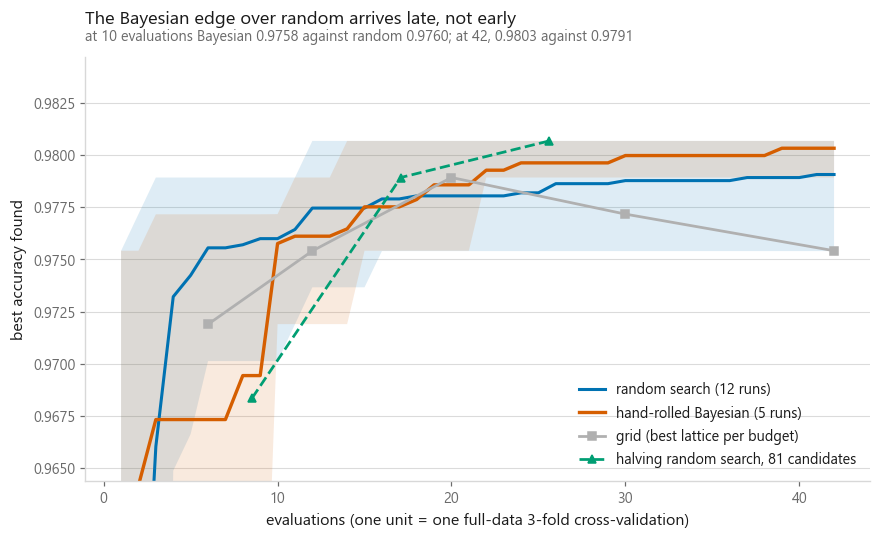

In [12]:
bayes_curves = np.array([
    np.maximum.accumulate(bayesian_search(N_EVAL, 8, seed=200 + s))
    for s in range(5)
])

evaluations = np.arange(1, N_EVAL + 1)

fig, ax = plt.subplots(figsize=(9.2, 5.0))

ax.fill_between(evaluations, random_curves.min(axis=0), random_curves.max(axis=0),
                color=style.PALETTE[0], alpha=0.13, lw=0)
ax.plot(evaluations, random_curves.mean(axis=0), color=style.PALETTE[0], lw=2.0,
        label="random search (12 runs)")

ax.fill_between(evaluations, bayes_curves.min(axis=0), bayes_curves.max(axis=0),
                color=style.HIGHLIGHT, alpha=0.13, lw=0)
ax.plot(evaluations, bayes_curves.mean(axis=0), color=style.HIGHLIGHT, lw=2.2,
        label="hand-rolled Bayesian (5 runs)")

ax.plot(grid_budgets, grid_best, marker=style.MARKERS[1], color=style.NEUTRAL,
        lw=1.8, label="grid (best lattice per budget)")
ax.plot(halving_cost, halving_best, marker=style.MARKERS[2], color=style.PALETTE[2],
        ls="--", lw=1.8, label="halving random search, 81 candidates")

pooled = np.concatenate([random_curves[:, 2:].ravel(), bayes_curves[:, 2:].ravel(),
                         np.array(grid_best), np.array(halving_best)])
ax.set_ylim(np.percentile(pooled, 3) - 0.004, pooled.max() + 0.004)
ax.set_xlabel("evaluations (one unit = one full-data 3-fold cross-validation)")
ax.set_ylabel("best accuracy found")
ax.legend(loc="lower right")
style.title(ax, "The Bayesian edge over random arrives late, not early",
            f"at 10 evaluations Bayesian {bayes_curves[:, 9].mean():.4f} against random "
            f"{random_curves[:, 9].mean():.4f}; at {N_EVAL}, "
            f"{bayes_curves[:, -1].mean():.4f} against {random_curves[:, -1].mean():.4f}")
style.save(fig, FIG / "fig-03-budget-curves.png")

for n in [10, 20, 42]:
    print(f"after {n:>2} evaluations: random {random_curves[:, n - 1].mean():.4f}, "
          f"bayesian {bayes_curves[:, n - 1].mean():.4f}")
print(f"halving reached {halving_best[-1]:.4f} at a cost of {halving_cost[-1]:.1f}")
print(f"grid reached    {grid_best[-1]:.4f} at a cost of {grid_budgets[-1]}")
best_lattice = int(np.argmax(grid_best))
print(f"grid's best lattice was {grid_best[best_lattice]:.4f} at a cost of "
      f"{grid_budgets[best_lattice]}, so the grid line is not monotone in its budget")

The result I went in expecting is not the one that came out. A Bayesian search is
meant to be at its best on a tiny budget, and on this objective it fails that
test. At ten evaluations it sits level with random search or a shade behind it,
and it only pulls ahead
once it has enough points for the surrogate to be worth consulting. Part of that
is by construction: the first eight evaluations of every Bayesian run are random
draws, because a Gaussian process fitted to nothing has nothing to say, and the
rest is that a Gaussian process fitted to a handful of points is mostly guessing.
If your budget really is ten evaluations, this method has not earned its extra
machinery yet.

All four converge to nearly the same place, because this objective has a broad
optimum and forty evaluations is plenty for two dimensions. The ordering at the
right-hand edge is close enough that I would not read much into it either.

The grid line goes down as well as up, and that is neither a plotting error nor a
best-so-far that lost its memory. Each point on it is a separate lattice, coarse
for a small budget and finer for a larger one, each finished and then read off.
Refining a lattice moves every point in it, so a finer grid can miss a corner that
a coarser one happened to land on and hand back a worse answer for more money. The
print says where the grid's own best sat, and it is not at the right-hand end.
This is a real property of grid search rather than an artefact of the plot: a grid
has no best-so-far, because until you have finished it you have no reason to think
the part you have done contains the answer. Random search and the Bayesian search
do have a best-so-far, which is why their curves can only rise.

Halving's marker sits far to the left for the score it reaches, which is the
point of it, and on this objective it lands highest for the least. A large pool of
candidates was screened for a fraction of what evaluating them all at full size
would have cost.

`HalvingGridSearchCV` does the same elimination to an ordinary grid, so it is the
cheapest change you can make to the search from section 2.

In [13]:
halving_grid = HalvingGridSearchCV(
    DecisionTreeClassifier(random_state=SEED), tree_grid,
    factor=3, resource="n_samples", min_resources=200,
    cv=StratifiedKFold(FOLDS, shuffle=True, random_state=SEED), n_jobs=-1,
)
start = time.perf_counter()
halving_grid.fit(X_bean, y_bean)
halving_wall = time.perf_counter() - start

print(f"full grid : {grid_wall:>5.1f} s, best CV score {search.best_score_:.4f}")
print(f"halving   : {halving_wall:>5.1f} s, best CV score {halving_grid.best_score_:.4f}")
print(f"speed-up  : {grid_wall / halving_wall:.1f}x")
print()
print(f"full grid picked : {search.best_params_}")
print(f"halving picked   : {halving_grid.best_params_}")

full grid :  16.1 s, best CV score 0.9000
halving   :   0.8 s, best CV score 0.8906
speed-up  : 21.4x

full grid picked : {'criterion': 'entropy', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 5}
halving picked   : {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1}


Halving can eliminate a candidate that would have won on the full data, because
it judges on a slice. That is the trade it makes. In practice the settings that
do badly on a fifth of the rows are rarely the ones that would have won.

## 5. Search space design and nested cross-validation

Two things decide whether a search works, and neither of them is the search
algorithm.

### Sample learning rates and penalties on a log scale

Learning rates, regularisation strengths, and SVM kernel widths are all
multiplicative quantities. The step from 0.001 to 0.01 changes the model as much
as the step from 0.1 to 1. A uniform sample over the range treats those two steps
as though the first were a hundredth as important as the second, and so puts
almost every draw in the top decade.

uniform draws below 0.01     : 0.8%
log-uniform draws below 0.01 : 50.0%

best found, uniform sampling     : 0.9655
best found, log-uniform sampling : 0.9759
log-uniform wins in 92% of the 12 runs


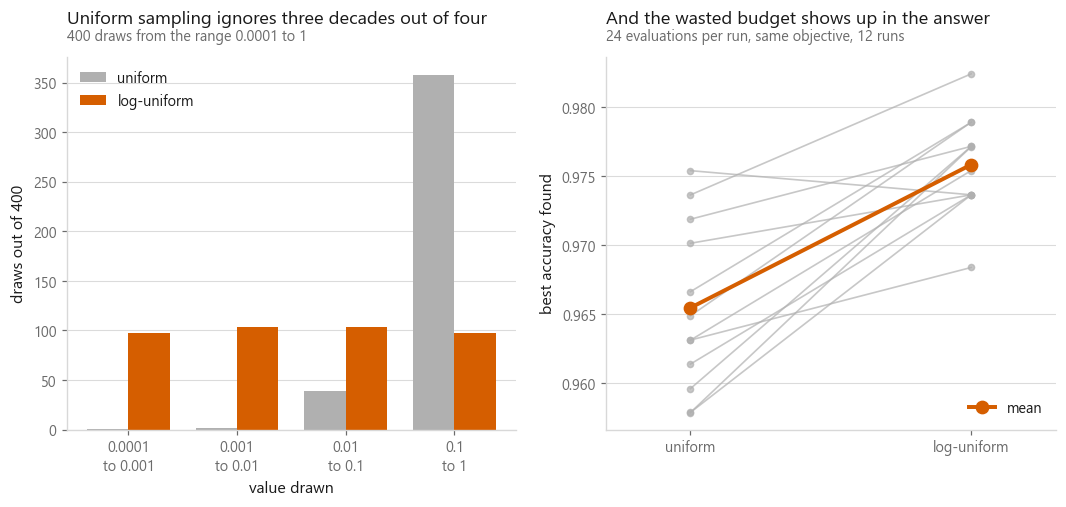

In [14]:
n_draw = 400
rng = np.random.default_rng(SEED)
uniform_draws = rng.uniform(1e-4, 1.0, n_draw)
log_draws = 10.0 ** rng.uniform(-4.0, 0.0, n_draw)

edges = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1e0])
decade_labels = ["0.0001\nto 0.001", "0.001\nto 0.01", "0.01\nto 0.1", "0.1\nto 1"]
count_uniform = np.histogram(uniform_draws, bins=edges)[0]
count_log = np.histogram(log_draws, bins=edges)[0]


def random_search_best(n_eval, seed, log_scale):
    """Same budget, same objective, different sampling distribution."""
    rng_local = np.random.default_rng(seed)
    if log_scale:
        pts = rng_local.uniform(BOX[:, 0], BOX[:, 1], size=(n_eval, 2))
    else:
        c = rng_local.uniform(10.0 ** BOX[0, 0], 10.0 ** BOX[0, 1], n_eval)
        g = rng_local.uniform(10.0 ** BOX[1, 0], 10.0 ** BOX[1, 1], n_eval)
        pts = np.column_stack([np.log10(c), np.log10(g)])
    return max(objective(p) for p in pts)


SEEDS = range(300, 312)
best_uniform = np.array([random_search_best(24, s, False) for s in SEEDS])
best_log = np.array([random_search_best(24, s, True) for s in SEEDS])

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))

x = np.arange(len(decade_labels))
axes[0].bar(x - 0.19, count_uniform, width=0.38, color=style.NEUTRAL, label="uniform")
axes[0].bar(x + 0.19, count_log, width=0.38, color=style.HIGHLIGHT, label="log-uniform")
axes[0].set_xticks(x, decade_labels)
axes[0].set_xlabel("value drawn")
axes[0].set_ylabel(f"draws out of {n_draw}")
axes[0].legend()
style.title(axes[0], "Uniform sampling ignores three decades out of four",
            "400 draws from the range 0.0001 to 1")

for u, l in zip(best_uniform, best_log):
    axes[1].plot([0, 1], [u, l], color=style.NEUTRAL, lw=1.1, marker="o", ms=4, alpha=0.7)
axes[1].plot([0, 1], [best_uniform.mean(), best_log.mean()], color=style.HIGHLIGHT,
             lw=2.6, marker=style.MARKERS[0], ms=8, zorder=4, label="mean")
axes[1].set_xticks([0, 1], ["uniform", "log-uniform"])
axes[1].set_xlim(-0.3, 1.3)
axes[1].set_ylabel("best accuracy found")
axes[1].legend(loc="lower right")
style.title(axes[1], "And the wasted budget shows up in the answer",
            "24 evaluations per run, same objective, 12 runs")
style.save(fig, FIG / "fig-04-log-uniform.png")

print(f"uniform draws below 0.01     : {(uniform_draws < 0.01).mean():.1%}")
print(f"log-uniform draws below 0.01 : {(log_draws < 0.01).mean():.1%}")
print()
print(f"best found, uniform sampling     : {best_uniform.mean():.4f}")
print(f"best found, log-uniform sampling : {best_log.mean():.4f}")
print(f"log-uniform wins in {(best_log > best_uniform).mean():.0%} of the 12 runs")

In scikit-learn that means `loguniform(1e-4, 1e0)` rather than `uniform(1e-4, 1)`
in a `param_distributions` dictionary, and `np.logspace(-4, 0, 5)` rather than
`np.linspace(1e-4, 1, 5)` in a `param_grid`. It is a one-word change that
recovers most of a wasted budget.

### The score from the search is too high

The second thing is subtler and it invalidates more published numbers than any
other mistake in this chapter.

`search.best_score_` is the maximum of many noisy estimates. Even if every
candidate were equally good, the maximum of many noisy measurements of the same
quantity lands above the truth, because taking a maximum selects for lucky
noise as much as for quality. This is the winner's curse, and it needs no data to
demonstrate.

In [15]:
rng = np.random.default_rng(SEED)
true_quality, noise_sd = 0.900, 0.020
print(f"every candidate is truly worth {true_quality:.3f}; "
      f"each measurement has noise {noise_sd:.3f}\n")
for m in [1, 5, 20, 100, 500]:
    draws = rng.normal(true_quality, noise_sd, size=(4000, m))
    winner = draws.max(axis=1).mean()
    print(f"{m:>4} candidates: reported best averages {winner:.4f}  "
          f"(inflated by {winner - true_quality:+.4f})")

every candidate is truly worth 0.900; each measurement has noise 0.020

   1 candidates: reported best averages 0.8997  (inflated by -0.0003)
   5 candidates: reported best averages 0.9232  (inflated by +0.0232)
  20 candidates: reported best averages 0.9375  (inflated by +0.0375)
 100 candidates: reported best averages 0.9501  (inflated by +0.0501)
 500 candidates: reported best averages 0.9606  (inflated by +0.0606)


Nothing about the models differed. The inflation is a property of the maximum.

The fix is **nested cross-validation**. The outer loop holds out a fold. The
search runs entirely inside the remaining data, choosing hyperparameters without
ever seeing the held-out fold. The chosen model is then scored on that fold. Do
that for every outer fold and the average is an estimate of how well *the whole
procedure*, search included, does on new data.

The inner loop chooses. The outer loop measures. Those are different jobs and
they need different data.

reported by the search : 0.9805
nested cross-validation: 0.9731
mean optimism          : +0.0074
trials where the search looked better: 9 of 10
time for 10 nested trials: 13.7 s


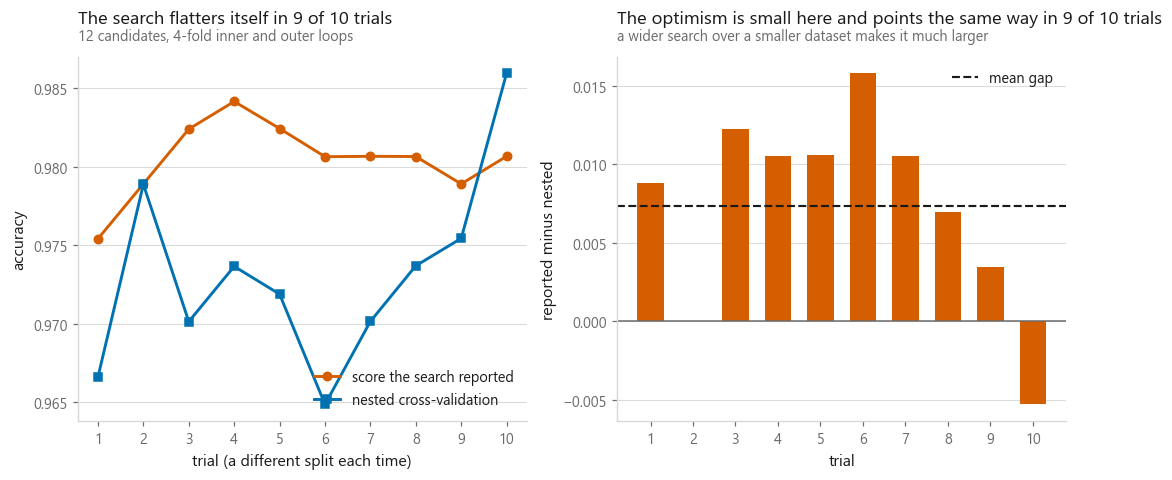

In [16]:
p_grid = {"svc__C": [0.1, 1.0, 10.0, 100.0],
          "svc__gamma": [1e-3, 1e-2, 1e-1]}
N_TRIALS = 10

nested = np.empty(N_TRIALS)
non_nested = np.empty(N_TRIALS)

start = time.perf_counter()
for i in range(N_TRIALS):
    inner = StratifiedKFold(4, shuffle=True, random_state=i)
    outer = StratifiedKFold(4, shuffle=True, random_state=i + 500)
    tuner = GridSearchCV(make_pipeline(StandardScaler(), SVC()), p_grid,
                         cv=inner, n_jobs=1)
    # The score the search reports about itself.
    tuner.fit(X_bc, y_bc)
    non_nested[i] = tuner.best_score_
    # The score of the same procedure on data the search never touched.
    nested[i] = cross_val_score(tuner, X_bc, y_bc, cv=outer, n_jobs=-1).mean()
nested_wall = time.perf_counter() - start

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))

trials = np.arange(1, N_TRIALS + 1)
axes[0].plot(trials, non_nested, marker=style.MARKERS[0], color=style.HIGHLIGHT,
             label="score the search reported")
axes[0].plot(trials, nested, marker=style.MARKERS[1], color=style.PALETTE[0],
             label="nested cross-validation")
axes[0].set_xlabel("trial (a different split each time)")
axes[0].set_ylabel("accuracy")
axes[0].set_xticks(trials)
axes[0].legend(loc="lower right")
style.title(axes[0], f"The search flatters itself in "
                     f"{(non_nested > nested).sum()} of {N_TRIALS} trials",
            f"{len(p_grid['svc__C']) * len(p_grid['svc__gamma'])} candidates, "
            "4-fold inner and outer loops")

gap = non_nested - nested
axes[1].bar(trials, gap, color=style.HIGHLIGHT, width=0.62)
axes[1].axhline(gap.mean(), color=style.INK, ls="--", lw=1.4, label="mean gap")
axes[1].axhline(0, color=style.MUTED, lw=1.0)
axes[1].set_xlabel("trial")
axes[1].set_ylabel("reported minus nested")
axes[1].set_xticks(trials)
axes[1].legend()
style.title(axes[1], f"The optimism is small here and points the same way in "
                     f"{(gap > 0).sum()} of {N_TRIALS} trials",
            "a wider search over a smaller dataset makes it much larger")
style.save(fig, FIG / "fig-05-nested-vs-not.png")

print(f"reported by the search : {non_nested.mean():.4f}")
print(f"nested cross-validation: {nested.mean():.4f}")
print(f"mean optimism          : {gap.mean():+.4f}")
print(f"trials where the search looked better: {(gap > 0).sum()} of {N_TRIALS}")
print(f"time for {N_TRIALS} nested trials: {nested_wall:.1f} s")

The gap is small on this dataset because the grid was narrow and the data is not
tiny. Widen the search, or shrink the data, and the gap grows: it scales with
how much freedom the search had to chase noise.

Not every trial came out the same way, and the chart titles count them. A gap this
small, measured against this much fold-to-fold noise, will sometimes reverse on a
single split. The bias lives in the average, not in every draw, which is precisely
why one trial is never enough to catch it.

Nested cross-validation costs the outer fold count times as much as a plain
search, which is why people skip it. Two things are worth saying about that. The
nested score is not the score of any one model, it is the score of the procedure,
so you still refit the search on all the data to get the model you ship. And if
you cannot afford the nested loop, a single held-out test set that the search
never sees does the same job with a noisier answer.

What you must not do is report `best_score_` as the performance of your model.
That number was chosen for being the largest.

## Cheat sheet

| | |
|---|---|
| **Grid search** | Exhaustive over the values you listed, $k^d$ evaluations. Fine for one or two hyperparameters, hopeless past three or four |
| **Random search** | Same budget, one distinct value per parameter per evaluation. The default choice when you do not know which hyperparameters matter |
| **Halving** | `HalvingRandomSearchCV` or `HalvingGridSearchCV`. Screens many candidates cheaply on a slice of the data. Best when candidates are many and each full fit is slow |
| **Bayesian** | Fits a surrogate to the scores so far and picks by expected improvement. Needs a warm-up of random draws before the surrogate is worth anything, so it trails random search over the first dozen evaluations and pulls ahead after. Worth it when each evaluation is expensive and the budget is large enough to cover that warm-up |
| **Scales** | `loguniform` and `np.logspace` for learning rates, C, alpha, gamma. Uniform sampling throws away most of the range |
| **Budget** | Spend it on more distinct values of the parameters that matter, not on finer coverage of the ones that do not |
| **Reporting** | Nested cross-validation, or a test set the search never saw. Never `best_score_` |
| **Next** | [Linear regression](../../02-regression/01-linear-regression/), where the tuning problem gets a closed-form answer for once |

## What to remember

1. A grid of $k$ values per parameter only ever tries $k$ distinct values of the
   parameter that matters, however large the budget. Random search tries one per
   evaluation.
2. That advantage exists because most hyperparameters do not matter much and you
   do not know in advance which ones. If they all matter the result reverses and
   the grid wins, which is what the control in section 3 measures.
3. Halving eliminates weak candidates on a small slice of the data first, so a
   large candidate pool costs a fraction of what it looks like it should.
4. A Bayesian search is a surrogate model plus an acquisition function. Expected
   improvement balances predicted score against uncertainty, and the uncertainty
   term is what stops it getting stuck.
5. Sample multiplicative hyperparameters on a log scale, or most of the budget
   lands in the top decade.
6. The score the search reports about itself is inflated, because it is a maximum
   over noisy estimates. Measure with a loop the search never saw.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [02-01 Linear regression](../../02-regression/01-linear-regression/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#HyperparameterTuning` `#RandomSearch` `#GridSearch`
`#BayesianOptimization` `#GaussianProcess` `#CrossValidation` `#Python`
`#ScikitLearn` `#DataScience`